In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('monthly_sunspots.csv')
df.head()

,Month,Sunspots
0,1749-01,58.0
1,1749-02,62.6
2,1749-03,70.0
3,1749-04,55.7
4,1749-05,85.0


In [3]:
#create dataset and add past values in X and new values in y
def create_dataset(data,timesteps):
    X,y = [],[]
    for i in range(len(data)-timesteps):
        X.append(data[i:i+timesteps])
        y.append(data[i+timesteps])
    return np.array(X),np.array(y)

In [4]:
#Scaling
y = df['Sunspots']
scaler = MinMaxScaler()
X_scaled=scaler.fit_transform(np.array(y).reshape(-1,1))

timesteps =12
X,y = create_dataset(X_scaled,timesteps)

In [5]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
from tensorflow.keras.layers import Input

Model = Sequential([Input(shape=(timesteps, 1)),
                   LSTM(64, return_sequences=True),
                   LSTM(32),
                   Dense(1, activation='linear')])

In [7]:
Model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['accuracy'])

Model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.0227 - loss: 0.0238 - val_accuracy: 0.0196 - val_loss: 0.0066
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0318 - loss: 0.0070 - val_accuracy: 0.0196 - val_loss: 0.0056
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0253 - loss: 0.0054 - val_accuracy: 0.0196 - val_loss: 0.0049
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0229 - loss: 0.0051 - val_accuracy: 0.0196 - val_loss: 0.0054
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0276 - loss: 0.0049 - val_accuracy: 0.0196 - val_loss: 0.0045
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0235 - loss: 0.0048 - val_accuracy: 0.0196 - val_loss: 0.0049
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.0235 - loss: 0.0047 - val_accuracy: 0.0196 - val_loss: 0.0042
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.0242 - loss: 0.0045 - val_accuracy: 0.0196 - v

In [8]:
# Make predictions
y_pred_scaled = Model.predict(X_test)

# Inverse transform the scaled predictions and actual values
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate evaluation metrics
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_original, y_pred)

print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'Mean Absolute Error (MAE): {mae}')

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Mean Squared Error (MSE): 277.84456304390983
Root Mean Squared Error (RMSE): 16.668670104237766
Mean Absolute Error (MAE): 12.014932596216847


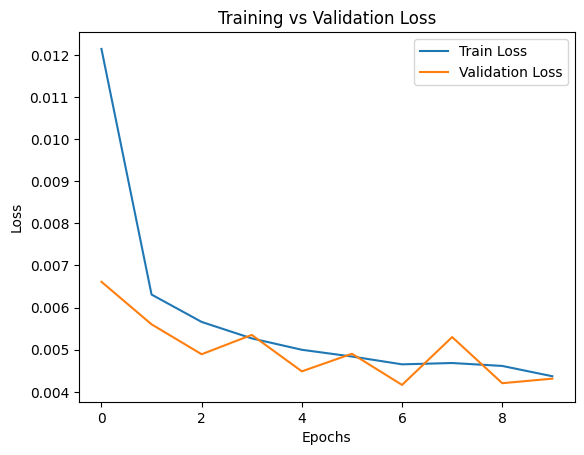

In [10]:
import matplotlib.pyplot as plt

plt.plot(Model.history.history['loss'], label='Train Loss')
plt.plot(Model.history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Save the plot image
plt.savefig('loss_plot.png')
plt.show()